In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

data_dir = f"{path}/Dataset_BUSI_with_GT"

Path to dataset files: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset


In [5]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import tensorflow as tf

In [6]:
classes = ['benign','malignant','normal']

images = []
labels = []

for label, cls in enumerate(classes):
    path = os.path.join(data_dir, cls)

    for img in os.listdir(path):

        # Ignore ground truth mask images
        if "mask" in img.lower():
            continue

        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (128,128))

        images.append(image)
        labels.append(label)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Dataset size:", images.shape)

Dataset size: (780, 128, 128, 3)


In [7]:
labels_cat = to_categorical(labels,3)

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    images,
    labels_cat,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [9]:
def create_model():

    model = Sequential()

    model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64,(3,3),activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128,(3,3),activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())

    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(3,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
model = create_model()

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773559011.068712      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/15


I0000 00:00:1773559014.094381     159 service.cc:152] XLA service 0x7e2628007640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773559014.094428     159 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773559014.446616     159 cuda_dnn.cc:529] Loaded cuDNN version 91002


11/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4013 - loss: 1.1784

I0000 00:00:1773559017.507820     159 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.4450 - loss: 1.1268 - val_accuracy: 0.6667 - val_loss: 0.9297
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5292 - loss: 0.9834 - val_accuracy: 0.6984 - val_loss: 0.8963
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6144 - loss: 0.8610 - val_accuracy: 0.6825 - val_loss: 0.8050
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6186 - loss: 0.7623 - val_accuracy: 0.7302 - val_loss: 0.8510
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7050 - loss: 0.6444 - val_accuracy: 0.7460 - val_loss: 0.8801
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6975 - loss: 0.6681 - val_accuracy: 0.6825 - val_loss: 0.9800
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7919 - loss: 0.5030 - val_accuracy: 0.7460 - val_loss: 1.0192
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8044 - loss: 0.4827 - val_accuracy: 0.6984 - val_loss: 1

In [11]:
def evaluate_model(model,X_test,y_test):

    pred = model.predict(X_test)
    pred_labels = np.argmax(pred,axis=1)
    true_labels = np.argmax(y_test,axis=1)

    acc = accuracy_score(true_labels,pred_labels)
    prec = precision_score(true_labels,pred_labels,average='weighted')
    rec = recall_score(true_labels,pred_labels,average='weighted')
    f1 = f1_score(true_labels,pred_labels,average='weighted')

    return acc,prec,rec,f1

In [12]:
base_results = evaluate_model(model,X_test,y_test)
print("Base CNN:",base_results)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step
Base CNN: (0.7435897435897436, 0.7502434385034203, 0.7435897435897436, 0.7391510329654186)


In [13]:
y_labels = np.argmax(y_train,axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))

In [14]:
model_weights = create_model()

model_weights.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    class_weight=class_weights
)

weights_results = evaluate_model(model_weights,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.4522 - loss: 1.1899
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4302 - loss: 1.0601
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5532 - loss: 0.9818
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6106 - loss: 0.8897
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6260 - loss: 0.8941
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6377 - loss: 0.7850
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6852 - loss: 0.7016
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7205 - loss: 0.6391
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7312 - loss: 0.5547
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8270 - loss: 0.4625
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8420 - loss: 0.3782
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy

In [15]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

model_aug = create_model()

model_aug.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=15
)

aug_results = evaluate_model(model_aug,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.4888 - loss: 1.0212
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5636 - loss: 0.9575
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6024 - loss: 0.8917
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.6492 - loss: 0.8281
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6509 - loss: 0.7867
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.6645 - loss: 0.8096
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.6828 - loss: 0.7517
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.6860 - loss: 0.7382
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.6805 - loss: 0.7065
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.6752 - loss: 0.7365
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6485 - loss: 0.7271
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - a

In [16]:
def focal_loss(gamma=2., alpha=.25):

    def loss(y_true,y_pred):

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred,epsilon,1-epsilon)

        cross_entropy = -y_true*tf.math.log(y_pred)
        weight = alpha*tf.math.pow(1-y_pred,gamma)

        return tf.reduce_sum(weight*cross_entropy,axis=1)

    return loss

In [17]:
model_focal = create_model()

model_focal.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

model_focal.fit(
    X_train,
    y_train,
    epochs=15
)

focal_results = evaluate_model(model_focal,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4802 - loss: 0.1298
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5931 - loss: 0.1018
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6321 - loss: 0.0894
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6608 - loss: 0.0808
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7433 - loss: 0.0632
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7771 - loss: 0.0517
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7775 - loss: 0.0483
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7776 - loss: 0.0463
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8232 - loss: 0.0382
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7937 - loss: 0.0399
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8596 - loss: 0.0367
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy

In [18]:
from imblearn.over_sampling import SMOTE

X_flat = X_train.reshape(len(X_train),-1)
y_labels = np.argmax(y_train,axis=1)

smote = SMOTE()

X_res,y_res = smote.fit_resample(X_flat,y_labels)

X_res = X_res.reshape(-1,128,128,3)
y_res = to_categorical(y_res)

In [19]:
model_smote = create_model()

model_smote.fit(
    X_res,
    y_res,
    epochs=15
)

smote_results = evaluate_model(model_smote,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.3982 - loss: 1.1043
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6642 - loss: 0.8281
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7393 - loss: 0.6667
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8022 - loss: 0.5429
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8928 - loss: 0.3143
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8927 - loss: 0.3116
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9163 - loss: 0.2219
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9507 - loss: 0.1549
Epoch 9/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9642 - loss: 0.1237
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9725 - loss: 0.1195
Epoch 11/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9820 - loss: 0.0619
Epoch 12/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy:

In [20]:
results = pd.DataFrame({
    "Model":[
        "Base CNN",
        "Class Weights",
        "Data Augmentation",
        "Focal Loss",
        "SMOTE"
    ],
    "Accuracy":[
        base_results[0],
        weights_results[0],
        aug_results[0],
        focal_results[0],
        smote_results[0]
    ],
    "Precision":[
        base_results[1],
        weights_results[1],
        aug_results[1],
        focal_results[1],
        smote_results[1]
    ],
    "Recall":[
        base_results[2],
        weights_results[2],
        aug_results[2],
        focal_results[2],
        smote_results[2]
    ],
    "F1 Score":[
        base_results[3],
        weights_results[3],
        aug_results[3],
        focal_results[3],
        smote_results[3]
    ]
})

print(results)

               Model  Accuracy  Precision    Recall  F1 Score
0           Base CNN  0.743590   0.750243  0.743590  0.739151
1      Class Weights  0.756410   0.765011  0.756410  0.759168
2  Data Augmentation  0.698718   0.700972  0.698718  0.673392
3         Focal Loss  0.769231   0.790402  0.769231  0.754643
4              SMOTE  0.782051   0.780203  0.782051  0.778468


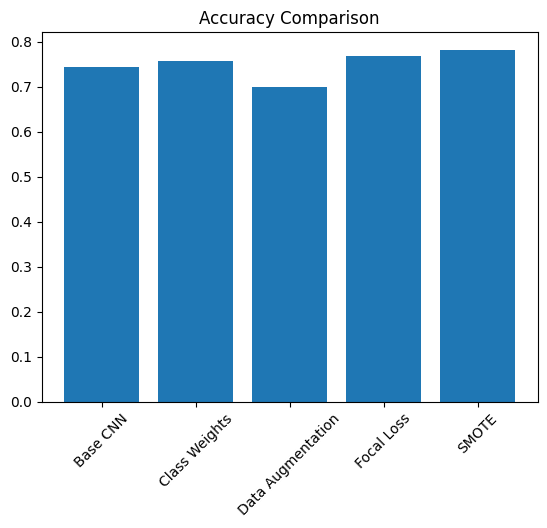

In [21]:
plt.figure()
plt.bar(results["Model"],results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()

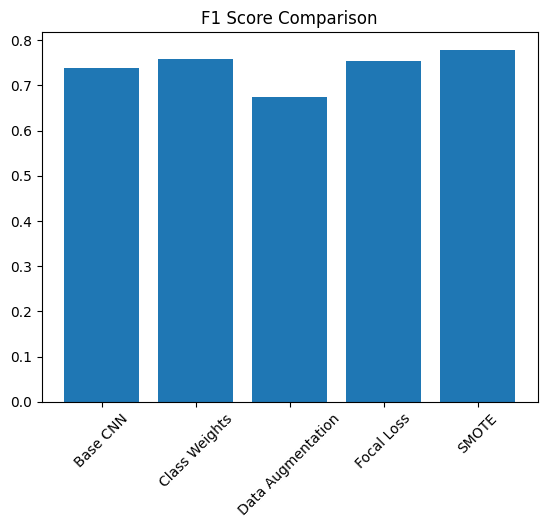

In [22]:
plt.figure()
plt.bar(results["Model"],results["F1 Score"])
plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.show()

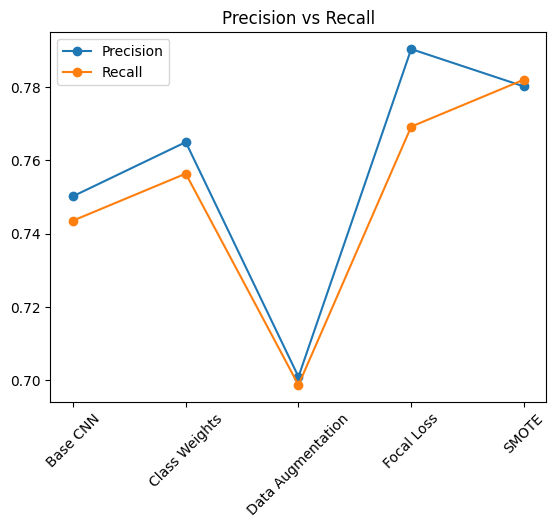

In [23]:
plt.figure()
plt.plot(results["Model"],results["Precision"],marker='o')
plt.plot(results["Model"],results["Recall"],marker='o')
plt.legend(["Precision","Recall"])
plt.xticks(rotation=45)
plt.title("Precision vs Recall")
plt.show()